In [1]:
import pandas as pd
import numpy as np
import sys
import os

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from data_science_utilities.models.xgb.feature_selection.recursive import classifier

In [2]:
TARGET = 'target_win'
RANDOM_SEED = 32
RFE_XGB_PARAMS = dict(
    n_estimators=5000,
    n_jobs=-1,
    learning_rate=.15,
    early_stopping_rounds=10,
    max_depth=5,
    eval_metric='auc',
    importance_type='total_gain',
    random_state=RANDOM_SEED
)
np.random.seed(RANDOM_SEED)

In [3]:
MODEL_FEATURES_BEFORE_RFE = pd.read_csv(
    '../../../../data/predict_games/model_features_in/xgb_features_list.csv'
)
INPUT_DATA = pd.read_parquet(
    '../../../../data/predict_games/input_data/schedule_and_weekly.parquet'
)

In [4]:
MODEL_FEATURES_BEFORE_RFE

,feature
0,season
1,week
2,div_game
3,target_days_since_previous_game
4,target_off_cumulative_score
...,...
341,def_target_special_teams_tds
342,def_target_special_teams_tds_cumulative_average
343,def_target_special_teams_tds_cumulative_averag...
344,is_home_target


In [5]:
INPUT_DATA

,game_id,season,week,opp_team,opp_score,target_team,target_score,div_game,target_days_since_previous_game,target_off_cumulative_score,...,def_target_racr_cumulative_average,def_target_racr_cumulative_average_change,def_target_wopr,def_target_wopr_cumulative_average,def_target_wopr_cumulative_average_change,def_target_special_teams_tds,def_target_special_teams_tds_cumulative_average,def_target_special_teams_tds_cumulative_average_change,is_home_target,target_win
0,2003_02_WAS_ATL,2003,2,WAS,33.0,ATL,31.0,0,7.0,27.0,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.0,0.0000,-0.062500,1,0
1,2003_02_CLE_BAL,2003,2,CLE,13.0,BAL,33.0,1,7.0,15.0,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.0,0.0000,-0.062500,1,1
2,2003_02_DET_GB,2003,2,DET,6.0,GB,31.0,1,7.0,25.0,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.0,0.0000,-0.125000,1,1
3,2003_02_TEN_IND,2003,2,TEN,7.0,IND,33.0,1,7.0,9.0,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.0,0.0000,-0.066667,1,1
4,2003_02_PIT_KC,2003,2,PIT,20.0,KC,41.0,0,7.0,27.0,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.0,0.0000,0.000000,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10773,2023_18_DEN_LV,2023,18,LV,27.0,DEN,14.0,1,7.0,343.0,...,7.170630,-0.305807,2.2,2.2,4.768372e-08,0.0,0.0000,0.000000,0,0
10774,2023_18_PHI_NYG,2023,18,NYG,27.0,PHI,10.0,1,7.0,423.0,...,15.925632,-0.091976,2.2,2.2,4.768372e-08,0.0,0.0000,0.000000,0,0
10775,2023_18_LA_SF,2023,18,SF,20.0,LA,21.0,1,7.0,383.0,...,10.673484,-0.055119,2.2,2.2,4.768372e-08,0.0,0.0000,0.000000,0,1
10776,2023_18_DAL_WAS,2023,18,WAS,10.0,DAL,38.0,1,8.0,471.0,...,5.111406,0.396310,2.2,2.2,4.768372e-08,0.0,0.0000,0.000000,0,1


In [6]:
model_inputs_df = INPUT_DATA[MODEL_FEATURES_BEFORE_RFE['feature']]
# randomize the data
model_inputs_df = model_inputs_df.sample(
    frac=1, random_state=RANDOM_SEED
).reset_index(drop=True)
model_inputs_df

,season,week,div_game,target_days_since_previous_game,target_off_cumulative_score,target_off_cumulative_avg_score,target_off_cumulative_avg_score_change,opp_days_since_previous_game,opp_off_cumulative_score,opp_off_cumulative_avg_score,...,def_target_racr_cumulative_average,def_target_racr_cumulative_average_change,def_target_wopr,def_target_wopr_cumulative_average,def_target_wopr_cumulative_average_change,def_target_special_teams_tds,def_target_special_teams_tds_cumulative_average,def_target_special_teams_tds_cumulative_average_change,is_home_target,target_win
0,2009,14,1,7.0,233.0,19.416667,-0.219697,6.0,323.0,26.916667,...,6.093145,-1.441764,2.2,2.2,-1.011473e-07,0.0,0.000000,0.000000,1,0
1,2021,11,1,10.0,177.0,17.700000,0.477778,7.0,161.0,17.888889,...,6.729427,0.167239,2.2,2.2,-1.271566e-07,0.0,0.000000,0.000000,0,1
2,2005,12,0,8.0,236.0,23.600000,-1.177778,8.0,305.0,30.500000,...,0.000000,0.000000,0.0,0.0,0.000000e+00,0.0,0.000000,0.000000,0,0
3,2011,16,1,9.0,207.0,14.785714,-0.060440,6.0,279.0,19.928571,...,5.025568,-0.051732,2.2,2.2,-8.383950e-08,0.0,0.000000,0.000000,0,0
4,2013,16,0,7.0,321.0,22.928571,0.543956,7.0,353.0,25.214286,...,3.515873,0.629704,2.2,2.2,5.239969e-08,0.0,0.000000,0.000000,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10773,2011,12,1,14.0,273.0,27.300000,1.077778,7.0,125.0,12.500000,...,3.651045,0.143618,2.2,2.2,-1.271566e-07,0.0,0.000000,0.000000,0,1
10774,2022,6,1,11.0,75.0,15.000000,-1.500000,8.0,122.0,24.400000,...,1.148187,-3.133311,2.2,2.2,-4.768372e-08,0.0,0.000000,0.000000,0,0
10775,2018,16,0,6.0,268.0,19.142857,-0.164835,6.0,265.0,18.928571,...,9.079201,0.044659,2.2,2.2,5.239969e-08,0.0,0.071429,-0.005495,1,1
10776,2019,5,0,10.0,85.0,21.250000,1.916667,7.0,107.0,26.750000,...,-12.759336,-4.425647,2.2,2.2,-7.947286e-08,0.0,0.000000,0.000000,0,1


# Create train, test, holdout
We use train at first here until cross validation is ready within a recursive feature elimination framework

In [7]:
# Train is all games before the 2023 season, holdout is 2023
train_df = model_inputs_df[(model_inputs_df['season'] < 2023)]
holdout_df = model_inputs_df[model_inputs_df['season'] == 2023]
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_holdout = holdout_df.drop(columns=[TARGET])
y_holdout = holdout_df[TARGET]

# Begin Recursive Feature Elimination

In [8]:
rfe = classifier.ClassifierRecursiveFeatureElimination(
    X_train, y_train, X_test, y_test, RFE_XGB_PARAMS, model_score_metric='roc_auc'
)

rfe.get_optimal_features(max_iter=20, verbose=1)

NameError: name 'X_test' is not defined

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Number of Features', ylabel='roc_auc'>)

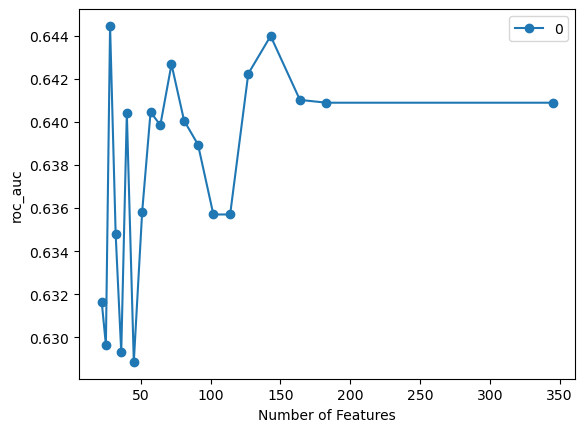

In [9]:
rfe.plot_model_scores()

In [10]:
features_df = rfe.get_features_in_dataframe()
features_df.to_csv('../../../../data/predict_games/model_features_in/rfe_features.csv')
features_df

,0,1,2,3,4,5,6,7,8,9,...,335,336,337,338,339,340,341,342,343,344
345,season,week,div_game,target_days_since_previous_game,target_off_cumulative_score,target_off_cumulative_avg_score,target_off_cumulative_avg_score_change,opp_days_since_previous_game,opp_off_cumulative_score,opp_off_cumulative_avg_score,...,def_target_racr,def_target_racr_cumulative_average,def_target_racr_cumulative_average_change,def_target_wopr,def_target_wopr_cumulative_average,def_target_wopr_cumulative_average_change,def_target_special_teams_tds,def_target_special_teams_tds_cumulative_average,def_target_special_teams_tds_cumulative_averag...,is_home_target
183,is_home_target,off_target_passing_epa_cumulative_average,opp_def_cumulative_avg_points_allowed,opp_off_cumulative_avg_score,off_opp_passing_epa_cumulative_average,target_off_cumulative_avg_score,target_def_cumulative_avg_points_allowed,off_opp_dakota_cumulative_average,off_opp_rushing_first_downs_cumulative_average,off_target_rushing_first_downs_cumulative_average,...,None,None,None,None,None,None,None,None,None,None
164,is_home_target,off_target_passing_epa_cumulative_average,opp_def_cumulative_avg_points_allowed,opp_off_cumulative_avg_score,off_opp_passing_epa_cumulative_average,target_off_cumulative_avg_score,target_def_cumulative_avg_points_allowed,off_target_rushing_first_downs_cumulative_average,def_target_rushing_yards_cumulative_average,off_opp_rushing_first_downs_cumulative_average,...,None,None,None,None,None,None,None,None,None,None
143,is_home_target,off_opp_passing_epa_cumulative_average,opp_def_cumulative_avg_points_allowed,target_off_cumulative_avg_score,target_def_cumulative_avg_points_allowed,off_target_passing_epa_cumulative_average,opp_off_cumulative_avg_score,def_opp_rushing_yards_cumulative_average,def_opp_carries_cumulative_average,def_target_rushing_yards_cumulative_average,...,None,None,None,None,None,None,None,None,None,None
127,is_home_target,opp_def_cumulative_avg_points_allowed,target_off_cumulative_avg_score,target_def_cumulative_avg_points_allowed,opp_off_cumulative_avg_score,off_target_passing_epa_cumulative_average,off_opp_passing_epa_cumulative_average,def_target_rushing_yards_cumulative_average,off_opp_dakota_cumulative_average,off_target_rushing_first_downs_cumulative_average,...,None,None,None,None,None,None,None,None,None,None
114,is_home_target,off_target_passing_epa_cumulative_average,opp_def_cumulative_avg_points_allowed,target_def_cumulative_avg_points_allowed,opp_off_cumulative_avg_score,off_opp_passing_epa_cumulative_average,off_opp_rushing_first_downs_cumulative_average,target_off_cumulative_avg_score,def_target_rushing_yards_cumulative_average,off_opp_dakota_cumulative_average,...,None,None,None,None,None,None,None,None,None,None
102,is_home_target,target_def_cumulative_avg_points_allowed,opp_def_cumulative_avg_points_allowed,opp_off_cumulative_avg_score,def_target_rushing_yards_cumulative_average,off_target_passing_epa_cumulative_average,off_opp_passing_epa_cumulative_average,target_off_cumulative_avg_score,def_opp_rushing_yards_cumulative_average,off_opp_rushing_first_downs_cumulative_average,...,None,None,None,None,None,None,None,None,None,None
91,is_home_target,target_def_cumulative_avg_points_allowed,opp_def_cumulative_avg_points_allowed,opp_off_cumulative_avg_score,off_target_passing_epa_cumulative_average,def_target_rushing_yards_cumulative_average,off_opp_passing_epa_cumulative_average,target_off_cumulative_avg_score,def_opp_rushing_yards_cumulative_average,off_opp_rushing_first_downs_cumulative_average,...,None,None,None,None,None,None,None,None,None,None
81,is_home_target,target_def_cumulative_avg_points_allowed,opp_def_cumulative_avg_points_allowed,opp_off_cumulative_avg_score,def_target_rushing_yards_cumulative_average,target_off_cumulative_avg_score,off_target_passing_epa_cumulative_average,def_opp_rushing_yards_cumulative_average,off_opp_passing_epa_cumulative_average,off_opp_rushing_first_downs_cumulative_average,...,None,None,None,None,Non

In [11]:
best_num_feats = rfe.get_best_num_features(.005)
best_num_feats

28

In [13]:
# These are the num feats and scores
rfe._get_metric_values()

,0
345,0.640887
183,0.640887
164,0.641018
143,0.643982
127,0.642234
114,0.635702
102,0.635702
91,0.638941
81,0.640060
72,0.642670
